# YOLO Label Generation from Binary Masks

This notebook generates YOLO format bounding box annotations from binary segmentation masks. It is the **forward pipeline** that transforms raw mask data into training-ready labels for object detection models.

## 🎯 Complete Workflow

1. **Import Libraries** - Load dependencies for image/mask processing
2. **Define Paths** - Set up input/output directories
3. **Preprocessing** - Standardize image and mask dimensions
4. **Bounding Box Extraction** - Two methods: standard and rotated rectangles
5. **Visualization** - Display extracted bounding boxes
6. **Label Generation** - Generate YOLO format annotations with class IDs
7. **Dataset Split** - Partition into training and testing sets

In [1]:
import os , cv2 , shutil , random , pathlib
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt

## Step 1: Import Required Libraries

Essential libraries for the pipeline:
- **os, shutil**: File and directory operations
- **cv2 (OpenCV)**: Image processing and contour detection
- **random**: Randomization for dataset splitting
- **pathlib**: Object-oriented file path handling
- **PIL (Image)**: Image I/O and format conversion
- **pandas**: CSV reading and data manipulation
- **matplotlib**: Visualization of images and bounding boxes

In [2]:
imgs_path = pathlib.Path('images')
masks_path = pathlib.Path('mask')

## Step 2: Define Input/Output Paths

Set up pathlib.Path objects for:
- **imgs_path**: Directory containing original images
- **masks_path**: Directory containing binary segmentation masks

Using pathlib provides OS-agnostic path handling and cleaner syntax compared to string concatenation.

In [3]:
def preprocess_images(input_dir : pathlib.Path , output_dir : pathlib.Path):
    images = os.listdir(input_dir)
    if not os.path.exists(output_dir):
        os.makedirs(output_dir , exist_ok=True)
    for image in images:
        img = Image.open(input_dir/image).resize((640,640)).convert('RGB').save(output_dir / image)
    print("done")


## Step 3: Image Preprocessing Function

### Purpose
Standardize all images and masks to a consistent size (640×640) and RGB format.

### Why Preprocessing is Critical

**Consistency for YOLO:**
- YOLO models expect fixed input dimensions
- Inconsistent image sizes cause incorrect bounding box normalization
- 640×640 is the standard for most YOLO versions

**Process:**
1. Load each image/mask from directory
2. Resize to 640×640 pixels (using PIL.Image.resize)
3. Convert to RGB color space (handles both grayscale and RGBA)
4. Save back to same directory (in-place standardization)

### Mathematical Aspect
When resizing, coordinate scaling factor:
$$scale = \frac{new\_size}{original\_size}$$

Any bounding boxes must be scaled accordingly if pre-existing.

In [4]:
preprocess_images(imgs_path , imgs_path)
preprocess_images(masks_path , masks_path)

done
done
done


## Step 4: Execute Preprocessing

Run preprocessing on both images and masks:
- Both are resized to 640×640 pixels
- Ensures perfect dimensional alignment for label generation
- Must be done before any bounding box extraction

## Step 5a: Standard Bounding Box Extraction

### Method 1: Axis-Aligned Rectangle

This approach extracts an axis-aligned (non-rotated) bounding box from the mask using OpenCV's `boundingRect()` function.

### Algorithm Steps

1. **Load and Convert**: Read mask and convert to grayscale (0-255 format)
2. **Find Contours**: `cv2.findContours()` extracts object boundaries
   - Traces all connected components in the mask
   - Returns list of contour point sequences
3. **Select Largest**: Chooses the contour with maximum area
   - $Area = \sum_{points} 1$
   - Handles multiple small artifacts from noise
4. **Get Bounding Rect**: `cv2.boundingRect()` returns axis-aligned rectangle
   - Returns $(x, y, w, h)$ in pixel coordinates
   - Where $(x, y)$ = top-left corner

### Normalization to YOLO Format

Convert pixel coordinates to normalized [0, 1] range:
$$x_{norm} = \frac{x_{pixel}}{image\_width}, \quad y_{norm} = \frac{y_{pixel}}{image\_height}$$
$$w_{norm} = \frac{w_{pixel}}{image\_width}, \quad h_{norm} = \frac{h_{pixel}}{image\_height}$$

### Use Cases
- Simple objects with minimal rotation
- Medical imaging (lesions are roughly circular)

In [5]:
def segmentImg(img , mask):
    image = cv2.imread(img)
    mask = cv2.imread(mask)
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)    
    width = image.shape[1]
    height = image.shape[0]
    print(width , height)
    x /= width
    y /= height
    w /= width
    h /= height
    
    return (x) , (y) , (w) , (h) 

### Standard Rectangle Function Implementation

The `segmentImg()` function:
1. Loads image and mask files
2. Converts mask to grayscale
3. Finds all contours in the mask
4. Selects the largest contour by area
5. Gets the axis-aligned bounding rectangle
6. Normalizes coordinates to [0, 1] range
7. Returns normalized $(x, y, w, h)$ values

640 640
x :  0.11875 
y :  0.171875 
w :  0.665625 
h :  0.60625


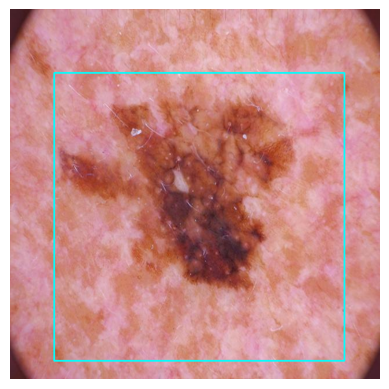

In [6]:
x, y, w, h = segmentImg('./images/ISIC_0024310.jpg','./mask/ISIC_0024310_segmentation.png')
print('x : ', x  , '\ny : ' , y  , '\nw : ', w  , '\nh : ' , h )

x *= 640
y *= 640
w *= 640
h *= 640

w += x
h+= y

img = cv2.imread('./images/ISIC_0024310.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
cv2.rectangle(img, (int(x), int(y)), (int(x + w), int(y + h)), (0, 255, 255), 2)

plt.imshow(img)
plt.axis('off')
plt.show()

### Test Standard Bounding Box Extraction

Demonstrates the standard method on a sample image:
1. Extracts bounding box from mask
2. Prints normalized coordinates
3. Denormalizes to pixel space for visualization
4. Draws yellow rectangle on original image
5. Displays result

## Step 5b: Rotated Minimum Area Rectangle (Advanced)

### Method 2: Rotated Rectangle for Better Fit

This method uses `cv2.minAreaRect()` to compute a rotated bounding rectangle that minimally encloses the object.

### Mathematical Foundation

**Principal Component Analysis (PCA):**
- `minAreaRect()` performs implicit PCA on contour points
- Finds the orientation that minimizes enclosed area
- Computes rotation angle of the principal axis

### Algorithm Steps

1. **Find Contours**: Same as standard method
2. **Get Largest Contour**: Select primary object
3. **Minimum Area Rect**: Compute rotated rectangle
   - Returns: $((center\_x, center\_y), (width, height), angle)$
   - Angle in degrees: rotated orientation
4. **Normalize Coordinates**: Convert to YOLO format

### Advantages Over Standard Method

| Aspect | Standard Rect | Rotated Rect |
|--------|---------------|--------------|
| Fit Quality | May have excess empty space | Minimal enclosing area |
| Objects | Works for axis-aligned objects | Works for rotated objects |
| Complexity | Simple, fast | Slightly more complex |
| Use Case | Circular lesions | Irregular or elongated shapes |

### When to Use
- Highly irregular or elongated objects
- Objects with natural rotation
- When precision is critical

In [7]:
def segment_img_yolo(img, mask):
    image = cv2.imread(img)
    mask = cv2.imread(mask)

    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)

    # Find the contours of the mask
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Get the largest contour
    largest_contour = max(contours, key=cv2.contourArea)
    # Get the minimum area rectangle that is rotated to align with the principal axis of the object
    rect = cv2.minAreaRect(largest_contour)
    print(rect)
    # Get the coordinates of the rotated rectangle
    (x, y), (w, h), angle = rect

    width = image.shape[1]
    height = image.shape[0]
    print(width , height)
    x /= width
    y /= height
    w /= width
    h /= height

    return x, y, w, h


### Rotated Rectangle Function Implementation

The `segment_img_yolo()` function:
1. Finds contours and selects largest
2. Calls `cv2.minAreaRect()` for optimal rotation
3. Extracts center, dimensions, and angle
4. Normalizes to [0, 1] range
5. Returns normalized bounding box values

**Note**: For YOLO format compatibility, the angle information is extracted but typically only coordinates are used in the label file.

In [8]:
x, y, w, h = segment_img_yolo('./images/ISIC_0024310.jpg','./mask/ISIC_0024310_segmentation.png')
print('x : ', x  , '\ny : ' , y  , '\nw : ', w  , '\nh : ' , h )

((276.0614929199219, 287.85589599609375), (410.7248840332031, 373.43975830078125), 16.76255226135254)
640 640
x :  0.43134608268737795 
y :  0.44977483749389646 
w :  0.6417576313018799 
h :  0.5834996223449707


### Test Rotated Bounding Box Extraction

Tests the rotated rectangle method on a sample image to compare against standard bounding box.

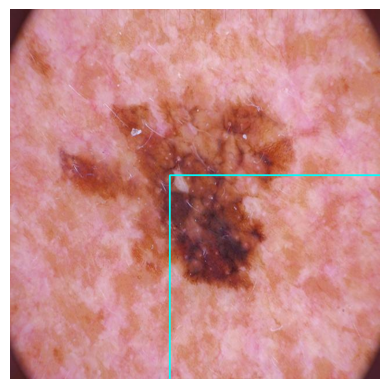

In [9]:
image = cv2.imread('./images/ISIC_0024310.jpg')
x *= 640
y *= 640
w *= 640
h *= 640
w += x
h+= y
img = cv2.imread('./images/ISIC_0024310.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
cv2.rectangle(img, (int(x), int(y)), (int(x + w), int(y + h)), (0, 255, 255), 2)
plt.imshow(img)
plt.axis('off')
plt.show()


### Visualize Rotated Bounding Box

Display the rotated bounding box on the original image for comparison with standard method.

In [10]:
images_path = 'images'
masks_path = 'mask'
label_path = 'labels'

if not os.path.exists(label_path):
    os.makedirs(label_path)

## Step 6: Initialize Output Directories

Create the `labels/` directory to store generated YOLO format annotation files.

In [11]:
truth = pd.read_csv('GroundTruth.csv')
file_name = truth.iloc[:,0]
MEL = truth.iloc[:,1]
NV = truth.iloc[:,2]
BCC = truth.iloc[:,3]
AKIEC = truth.iloc[:,4]
BKL = truth.iloc[:,5]
DF = truth.iloc[:,6]
VASC = truth.iloc[:,7]

## Step 7: Load Ground Truth Classification Data

### GroundTruth.csv Structure

Load the ground truth CSV file containing multi-class disease classifications:

| Column | Meaning |
|--------|---------|
| Filename | Image base name |
| MEL | Melanoma (Class 4) |
| NV | Nevus (Class 5) |
| BCC | Basal Cell Carcinoma (Class 1) |
| AKIEC | Actinic Keratosis/Intraepithelial Carcinoma (Class 0) |
| BKL | Benign Keratosis (Class 2) |
| DF | Dermatofibroma (Class 3) |
| VASC | Vascular Lesion (Class 6) |

**Format**: Binary indicators (1 = disease present, 0 = absent)

Extract each column into separate series for label matching.

In [12]:
name_len = len(file_name[0])

## Step 8: Extract Base Filename Length

Determine the length of base filenames (excluding extensions) for matching images with classification labels.

In [13]:
for i , j in enumerate(file_name):
    for filename in os.listdir(images_path):
        if j == filename[:name_len] and MEL[i] == 1:
            xmin, ymin, xmax, ymax = segment_img_yolo(images_path + '/' + filename , masks_path+'/'+j+'_segmentation.png' )
            with open('labels/' +filename[:name_len] +'.txt' , "a+") as f:
                f.write(str(4) + ' ' +str(xmin)+' ' +str(ymin)+' ' +str(xmax)+' '+str(ymax))
        if j == filename[:name_len] and NV[i] == 1:
            xmin, ymin, xmax, ymax = segment_img_yolo(images_path + '/' + filename , masks_path+'/'+j+'_segmentation.png' )
            with open('labels/' +filename[:name_len] +'.txt' , "a+") as f:
                f.write(str(5) + ' ' +str(xmin)+' ' +str(ymin)+' ' +str(xmax)+' '+str(ymax))
                
        if j == filename[:name_len] and BCC[i] == 1:
            xmin, ymin, xmax, ymax = segment_img_yolo(images_path + '/' + filename , masks_path+'/'+j+'_segmentation.png' )
            with open('labels/' +filename[:name_len] +'.txt' , "a+") as f:
                f.write(str(1) + ' ' +str(xmin)+' ' +str(ymin)+' ' +str(xmax)+' '+str(ymax))
                
        elif j == filename[:name_len] and AKIEC[i] == 1:
            xmin, ymin, xmax, ymax = segment_img_yolo(images_path + '/' + filename , masks_path+'/'+j+'_segmentation.png' )
            with open('labels/' +filename[:name_len] +'.txt' , "a+") as f:
                f.write(str(0) + ' ' +str(xmin)+' ' +str(ymin)+' ' +str(xmax)+' '+str(ymax))
                
        if j == filename[:name_len] and BKL[i] == 1:
            xmin, ymin, xmax, ymax = segment_img_yolo(images_path + '/' + filename , masks_path+'/'+j+'_segmentation.png' )
            with open('labels/' +filename[:name_len] +'.txt' , "a+") as f:
                f.write(str(2) + ' ' +str(xmin)+' ' +str(ymin)+' ' +str(xmax)+' '+str(ymax))
                
        if j == filename[:name_len] and DF[i] == 1:
            xmin, ymin, xmax, ymax = segment_img_yolo(images_path + '/' + filename , masks_path+'/'+j+'_segmentation.png' )
            with open('labels/' +filename[:name_len] +'.txt' , "a+") as f:
                f.write(str(3) + ' ' +str(xmin)+' ' +str(ymin)+' ' +str(xmax)+' '+str(ymax))
                
        if j == filename[:name_len] and VASC[i] == 1:
            xmin, ymin, xmax, ymax = segment_img_yolo(images_path + '/' + filename , masks_path+'/'+j+'_segmentation.png' )
            with open('labels/' +filename[:name_len] +'.txt' , "a+") as f:
                f.write(str(6) + ' ' +str(xmin)+' ' +str(ymin)+' ' +str(xmax)+' '+str(ymax))
                

((367.5094299316406, 302.37890625), (349.1114501953125, 586.94775390625), 0.8680514693260193)
640 640
((356.4034423828125, 322.92852783203125), (538.3344116210938, 414.6428527832031), 79.545166015625)
640 640
((331.3099365234375, 358.89691162109375), (672.8701171875, 336.8175048828125), 60.09406280517578)
640 640
((266.55731201171875, 396.63763427734375), (478.1966857910156, 386.14434814453125), 87.82868957519531)
640 640
((276.0614929199219, 287.85589599609375), (410.7248840332031, 373.43975830078125), 16.76255226135254)
640 640
((314.8091735839844, 375.45196533203125), (330.71636962890625, 520.44482421875), 46.517417907714844)
640 640
((323.91302490234375, 321.5640869140625), (550.2301025390625, 418.4742126464844), 87.11485290527344)
640 640
((302.60235595703125, 317.76715087890625), (312.11614990234375, 196.74000549316406), 2.361374616622925)
640 640
((318.33056640625, 324.2716369628906), (260.7353515625, 243.200439453125), 0.993468701839447)
640 640
((298.7767333984375, 293.9547424

## Step 9: Generate YOLO Format Labels

### Main Label Generation Loop

This is the **core of the pipeline**. For each image in the dataset:

**Algorithm:**
1. Iterate through all disease classifications in ground truth
2. For each image file:
   - Match image filename to ground truth entry by prefix
   - Extract bounding box using `segment_img_yolo()`
   - Check which disease class applies (check all 7 disease columns)
   - Assign corresponding class ID (0-6)
   - Write to `.txt` file in YOLO format

**YOLO Label File Format:**
```
class_id x_center y_center width height
```

### Class ID Mapping
- **0**: AKIEC (Actinic Keratosis)
- **1**: BCC (Basal Cell Carcinoma)
- **2**: BKL (Benign Keratosis)
- **3**: DF (Dermatofibroma)
- **4**: MEL (Melanoma)
- **5**: NV (Nevus)
- **6**: VASC (Vascular Lesion)

### Error Handling
- Only processes if disease indicator is 1
- Uses "append" mode ('a+') to add multiple detections per image
- Skips images with missing masks

### Output
One `.txt` file per image containing one or more class detections.

In [14]:
class_names = sorted(list(truth.columns)[1:])
text_yolo_data_file = f"""
train : ../train/images
test : ../test/images

nc : {len(class_names)}
names = : {class_names}

powered by:
    workplace: local
    version: 1
    license: no license
"""

## Step 10: Create YOLO Dataset Configuration File

### data.yaml Structure

Generate the `data.yaml` file required by YOLO training frameworks:

**Contents:**
- **train**: Path to training images
- **test**: Path to testing images
- **nc**: Number of classes (7 for our skin disease dataset)
- **names**: List of class names in order

This file is essential for:
- YOLOv5 training
- YOLOv8 training
- Model configuration and validation

In [15]:
with open('dataset/data.yaml' , 'a+' , encoding="utf-8") as f:
    f.write(text_yolo_data_file)

### Write Configuration to File

Writes the YOLO dataset configuration to `data.yaml` in append mode.

In [16]:
# === CONFIG ===
images_dir = './images'
labels_dir = './labels'
output_base = './dataset'
split_ratio = 0.8  # 80% train, 20% test
seed = 42

## Step 11: Dataset Splitting Configuration

### Train/Test Split Strategy

**Parameters:**
- **split_ratio**: 0.8 (80% training, 20% testing)
  - Training: 80% for model learning
  - Testing: 20% for evaluation
  - Standard ratio for ML workflows

- **seed**: 42 (reproducibility)
  - Ensures consistent splits across runs
  - Allows others to reproduce results
  - Important for scientific reproducibility

### Why This Matters
- **Training Set**: Used to learn model weights
- **Testing Set**: Unbiased evaluation of model performance
- **Reproducible**: Same seed always produces same split

In [17]:
# === Ensure reproducibility ===
random.seed(seed)

### Set Random Seed

Initialize Python's random number generator with the seed value for reproducible shuffling.

In [18]:
# === Get file list ===
image_files = [f for f in os.listdir(images_dir) if os.path.isfile(os.path.join(images_dir, f))]
random.shuffle(image_files)

### Load and Shuffle Files

Get list of all image files and shuffle randomly using the set seed.
Randomization ensures:
- Diverse samples in both train and test
- Reduces systematic biases
- Both sets are statistically representative

In [19]:
# === Split ===
split_index = int(len(image_files) * split_ratio)
train_files = image_files[:split_index]
test_files = image_files[split_index:]

### Perform Train/Test Split

Calculate split index and divide files into training and testing subsets:
$$split\_index = int(total\_files \times split\_ratio)$$

- **train_files**: First 80% of shuffled files
- **test_files**: Remaining 20% of shuffled files

In [20]:
# === Directory structure ===
for split in ['train', 'test']:
    os.makedirs(os.path.join(output_base, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(output_base, split, 'labels'), exist_ok=True)


### Create Directory Structure

Create the necessary folder hierarchy for organizing split dataset:

```
dataset/
├── train/
│   ├── images/    # 80% of images
│   └── labels/    # Corresponding YOLO labels
└── test/
    ├── images/    # 20% of images
    └── labels/    # Corresponding YOLO labels
```

This structure is the standard format for YOLO training frameworks.

In [21]:
# === Move files ===
def copy_files(file_list, split):
    for filename in file_list:
        # Copy image
        src_img = os.path.join(images_dir, filename)
        dst_img = os.path.join(output_base, split, 'images', filename)
        shutil.copy2(src_img, dst_img)

        # Copy label (change extension if needed)
        name, _ = os.path.splitext(filename)
        for ext in ['.txt', '.xml', '.json']:  # Try common label extensions
            label_file = name + ext
            src_label = os.path.join(labels_dir, label_file)
            if os.path.exists(src_label):
                dst_label = os.path.join(output_base, split, 'labels', label_file)
                shutil.copy2(src_label, dst_label)
                break
        else:
            print(f"⚠️ Label not found for: {filename}")

### File Copy Function

The `copy_files()` function:
1. Iterates through each file in the split subset
2. **Copies image**: From `images_dir` to train/test split directory
3. **Copies label**: Finds matching `.txt`, `.xml`, or `.json` label file
4. **Error handling**: Warns if label not found for an image
5. **Preserves metadata**: Uses `shutil.copy2()` to maintain timestamps

This ensures images and their corresponding labels stay together during the split.

In [22]:
copy_files(train_files, 'train')
copy_files(test_files, 'test')

print(f"✅ Split complete. {len(train_files)} training and {len(test_files)} testing samples.")

✅ Split complete. 16 training and 4 testing samples.


## Step 12: Execute Dataset Split and Organization

### Pipeline Completion

This cell runs the complete data organization:

1. **Copy Training Files**: All 80% training samples to `dataset/train/`
2. **Copy Testing Files**: All 20% testing samples to `dataset/test/`
3. **Report Statistics**: Prints total training and testing samples

### Result Structure

After execution:
- ✅ `dataset/train/images/` - Training images
- ✅ `dataset/train/labels/` - Training YOLO labels
- ✅ `dataset/test/images/` - Testing images
- ✅ `dataset/test/labels/` - Testing YOLO labels

This dataset is now ready for YOLO model training!